# imports

In [1]:
import os
import networkx as nx
from grakel import graph_from_networkx, SubgraphMatching
import torch
from torch_geometric.data.data import Data as torch_geometric_data
from subgraph_matching_via_nn.data.annotated_graph import GraphConstants, AnnotatedGraph
from subgraph_matching_via_nn.data.paths import DATA_PATH
from subgraph_matching_via_nn.data.data_loaders import load_graph
from subgraph_matching_via_nn.utils.plot_services import PlotServices
from subgraph_matching_via_nn.graph_processors.graph_processors import GraphProcessor

In [2]:
n_workers = os.cpu_count()

# kernel definition

In [3]:
NODE_ATTRIBUTE_NAME = 'attributes'

def set_graphs_attributes(nx_graphs, attribute_name):
    for nx_graph in nx_graphs:
        nx.set_node_attributes(nx_graph, 1, attribute_name)

def fit_kernel(nx_graphs):
    # G3 = nx.Graph()
    # G3.add_nodes_from([0,1,2])
    # G3.add_edges_from([(0,1), (0,2), (1,2)])
    # nx.set_node_attributes(G3, {0:1.8,
    #     1:0.2, 2:2.3}, NODE_ATTRIBUTE_NAME)

    K = max([len(nx_graph) for nx_graph in nx_graphs])
    ker = SubgraphMatching(ke=None, k=K) #we dont use edge labels/attributes

    set_graphs_attributes(nx_graphs, NODE_ATTRIBUTE_NAME)

    # Transforms list of NetworkX graphs into a list of GraKeL graphs
    G_list = graph_from_networkx(nx_graphs, node_labels_tag=NODE_ATTRIBUTE_NAME) # we have to set labels/attributes for either nodes or edges
    G_list = [g for g in G_list]

    # Fit on target subgraphs
    ker.fit(G_list)

    return ker, K

# load subgraph instance data

In [4]:
# take full graph with 3 subgraphs, 2 which are there and 1 which is not there

sub_graphs = []
for subgraph_index in [0, 1, 2, 3]:

    loader_params = {'data_path' : DATA_PATH,
                     'g_full_path': 'comp3_4_4/full_graph.p',
                     'g_sub_path': f'comp3_4_4/subgraph{subgraph_index}.p'}

    sub_graph = \
        load_graph(type='subcircuit',
                   loader_params=loader_params) # type = 'random', 'example', 'subcircuit'
    sub_graphs.append(sub_graph)

In [5]:
# use name to recognize the subgraph type [see https://github.com/lazriel/Scandid/blob/master/benchmarks/basic/comp3/netlist/comp3.info]
for sub_graph in sub_graphs:
    print(sub_graph.G_sub.name)

reference_subgraphs_indices = [1, 3]

counter_1
rf
counter_2
subtractor


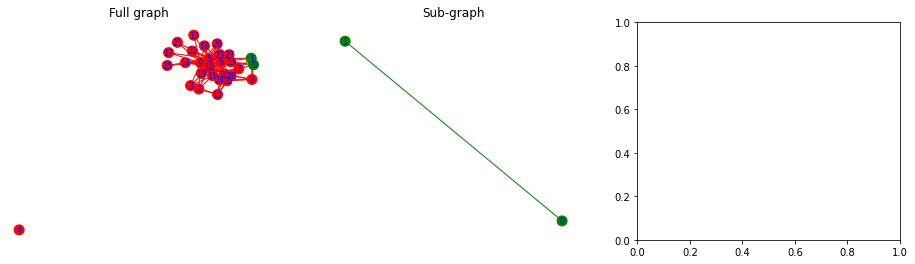

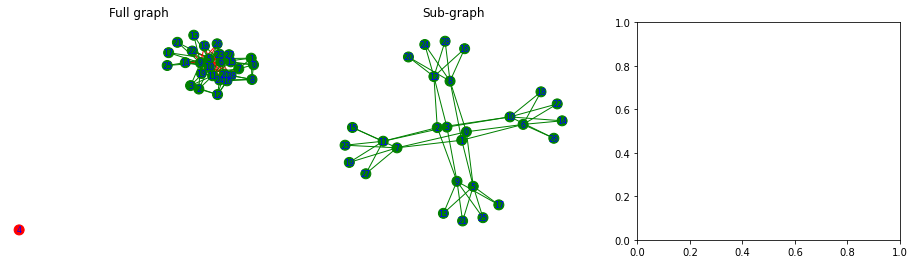

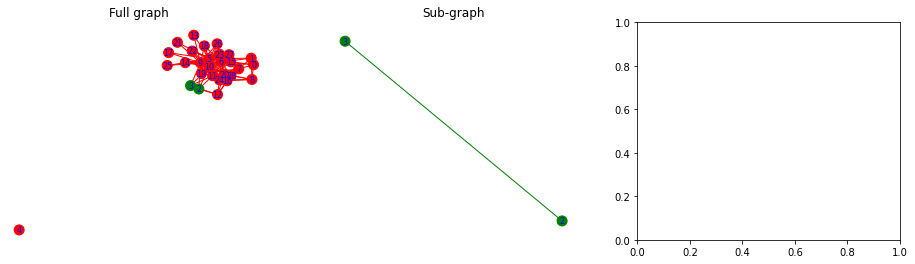

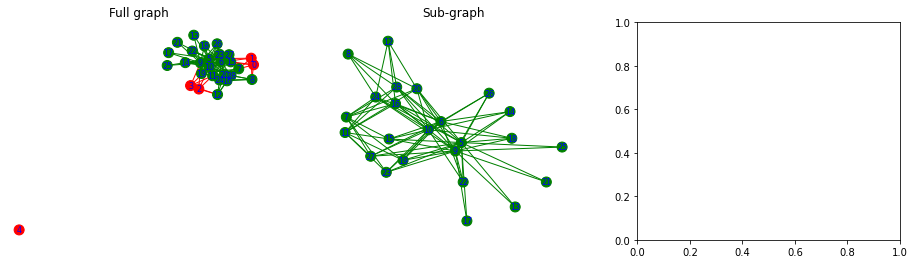

In [6]:
seed = 10  # for plotting
plot_services = PlotServices(seed)

for sub_graph in sub_graphs:
    _ = plot_services.plot_graph_alongside_subgraph(sub_graph, is_show_plot=True, n_subplots=3)

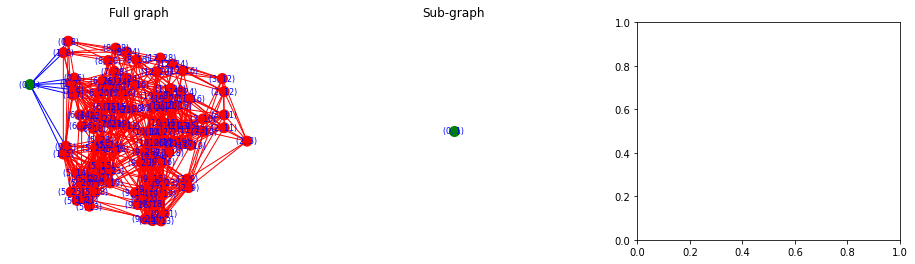

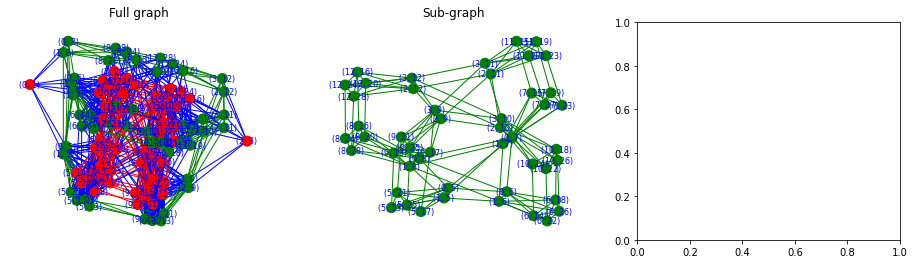

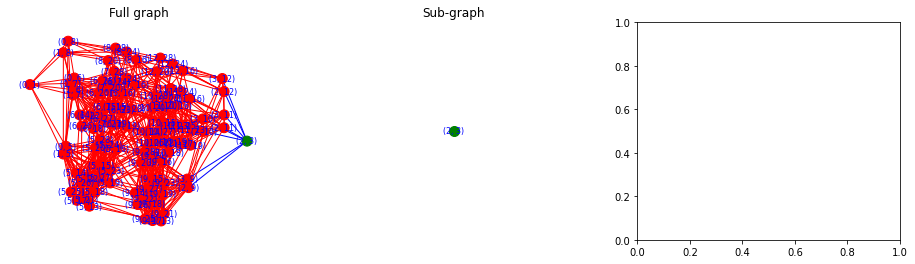

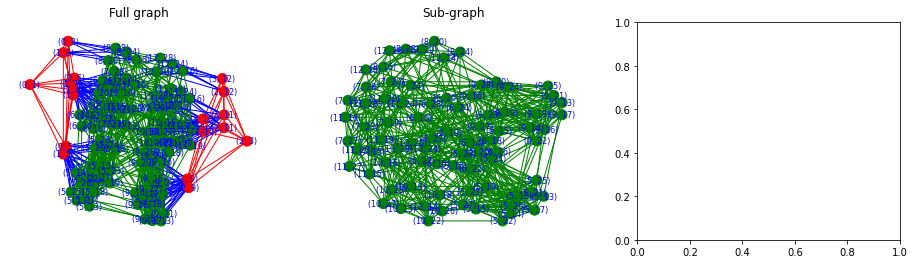

In [7]:
to_line = True

graph_processor = GraphProcessor(params={'to_line':  to_line})#, 'to_undirected': 'symmetrize'})

processed_sub_graphs = []

for sub_graph in sub_graphs:

    processed_sub_graph = graph_processor.pre_process(sub_graph)
    processed_sub_graphs.append(processed_sub_graph)

    _ = plot_services.plot_graph_alongside_subgraph(processed_sub_graph, is_show_plot=True, n_subplots=3)

In [8]:
nx_reference_subgraphs = [processed_sub_graphs[i].G_sub for i in reference_subgraphs_indices]
nx_source_graph = processed_sub_graphs[0].G

# Fit kernel on subgraphs

In [9]:
ker, K = fit_kernel(nx_reference_subgraphs)

# extract node subgraphs

In [10]:
# R is the diameter of the small graph
#     *'exract subgraphs around node' -> as we may not have radius shaped subgraph
#         neuro -> decompose function (used nx.ego_graph()
#     * we can try and play with this module, instead of using radius based subgraph, extract other subgraphs
#         as our subgraphs do not necessarily follow this pattern

In [11]:
#TODO: the following functions are copied and duplicated from the SubgraphMatchingLearning REPO

def convert_edge_list_into_tensor(edge_list):
    edge_index_source = [e[0] for e in edge_list]  # [2, node indices]
    edge_index_target = [e[1] for e in edge_list]  # [2, node indices]
    edge_index = torch.LongTensor([edge_index_source, edge_index_target])

    return edge_index

def get_node_features(nx_graph: [nx.Graph], device="cpu", feature_size=1, should_remove_existing_features=False):
    if should_remove_existing_features or ('x' not in nx_graph):
        default_node_features = [[1 for i in range(feature_size)] for _ in list(nx_graph.nodes)]
        x = torch.tensor(default_node_features).reshape(len(nx_graph.nodes()), -1) \
            .type(dtype=torch.float).to(device)  # [node_amount, feature vector]
    else:
        x = nx_graph['x']
    return x

def convert_nx_graph_into_torch_geometric_data(graph: AnnotatedGraph, device, feature_size=1, should_remove_existing_features=False,
                                               batch_id=None, y=None, use_edge_attr=True, edge_weight_attribute_name=GraphConstants.EDGE_WEIGHT_ATTRIBUTE_NAME):
    nx_graph = graph.g
    x = get_node_features(nx_graph, device=device, feature_size=feature_size,
                          should_remove_existing_features=should_remove_existing_features)

    edge_attr = None
    edges_with_values = nx_graph.edges(data=True)
    edge_index = convert_edge_list_into_tensor(edges_with_values).to(device)

    if use_edge_attr:
        if len(edges_with_values) != 0:
            try:
                edge_attr = graph.get_edge_attributes_vector(edge_weight_attribute_name)
            except ValueError:
                edge_attr = torch.ones((len(edges_with_values), 1), device=device)

    graph_data = torch_geometric_data(x=x, edge_index=edge_index, batch_id=batch_id, edge_attr=edge_attr, y=y)
    graph_data.edge_index = edge_index
    return graph_data

In [12]:
from common.graph_utils import GraphNeighbourhoodsDecomposer

SUBGRAPH_RADIUS = K
device = 'cpu'

annotated_graph = AnnotatedGraph(g=nx_source_graph, label=None)
source_graph_tg = convert_nx_graph_into_torch_geometric_data(annotated_graph, device, should_remove_existing_features=False, use_edge_attr=False)
nx_node_subgraphs = GraphNeighbourhoodsDecomposer.decompose([source_graph_tg], n_hops=SUBGRAPH_RADIUS, n_workers=n_workers,
                                 take_only_directed_edges=False,
                                 is_convert_node_labels_to_integers=False)

decompose into neighborhoods


graphs:   0%|          | 0/1 [00:00<?, ?it/s]

n_workers: 8



graphs: 100%|██████████| 1/1 [00:13<00:00, 13.91s/it]


# Get kernel values for input graph

In [13]:
# Transforms list of NetworkX graphs into a list of GraKeL graphs
set_graphs_attributes(nx_node_subgraphs, NODE_ATTRIBUTE_NAME)
node_subgraphs = graph_from_networkx(nx_node_subgraphs, node_labels_tag=NODE_ATTRIBUTE_NAME)
node_subgraphs = [g for g in node_subgraphs]

In [14]:
node_kernel_scores = ker.transform(node_subgraphs)

In [15]:
node_kernel_scores

array([[4608., 7680.],
       [4272., 7120.],
       [4080., 6800.],
       [4032., 6720.],
       [3888., 6480.],
       [3648., 6080.],
       [3984., 6640.],
       [3600., 6000.],
       [3744., 6240.],
       [3312., 5520.],
       [3216., 5360.],
       [2928., 4880.],
       [2880., 4800.],
       [2736., 4560.],
       [2688., 4480.],
       [2640., 4400.],
       [3600., 6000.],
       [3552., 5920.],
       [3168., 5280.],
       [3120., 5200.],
       [3072., 5120.],
       [2544., 4240.],
       [3072., 5120.],
       [3024., 5040.],
       [2928., 4880.],
       [2880., 4800.],
       [3120., 5200.],
       [3072., 5120.],
       [3024., 5040.],
       [2976., 4960.],
       [2784., 4640.],
       [2592., 4320.],
       [2112., 3520.],
       [2496., 4160.],
       [2832., 4720.],
       [2736., 4560.],
       [2544., 4240.],
       [2400., 4000.],
       [2064., 3440.],
       [2016., 3360.],
       [2256., 3760.],
       [2160., 3600.],
       [1248., 2080.],
       [105

In [16]:
node_kernel_scores.shape

(98, 2)